Data lest inn OK!
Antall rader totalt: 73



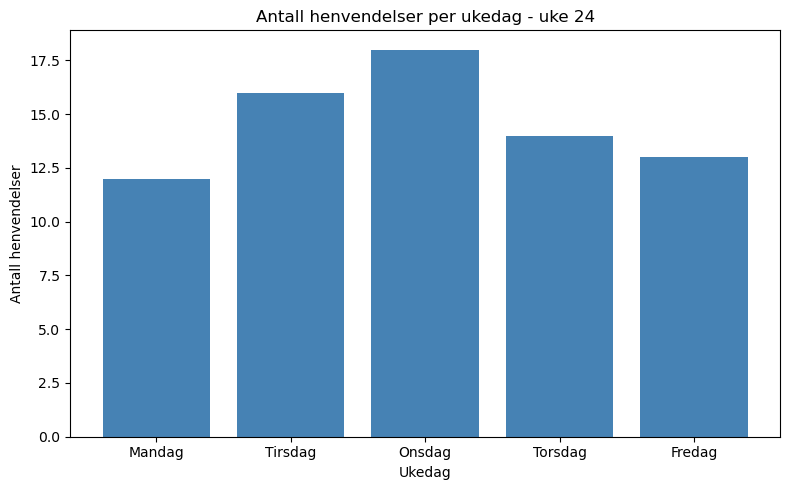

Del b) ferdig

Del c)
Korteste samtale: 49 sekunder
Lengste samtale:  1074 sekunder

Del d)
Gjennomsnittlig samtaletid: 559.7 sekunder

Del e) antall per tidsrom:
  08-10: 21 henvendelser
  10-12: 18 henvendelser
  12-14: 21 henvendelser
  14-16: 13 henvendelser


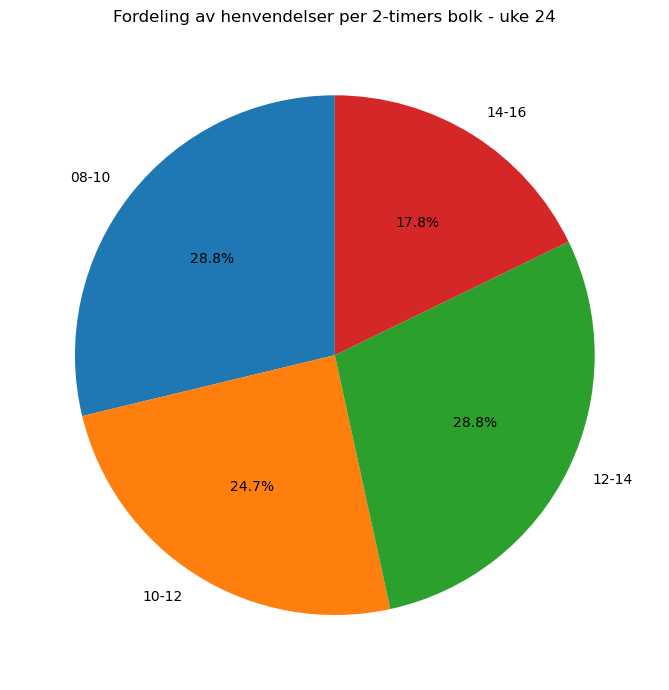

sektordiagram lagret

Del f) NPS:
  Antall som svarte: 57
  Negative (1-6):    12  (21.1%)
  Noytrale (7-8):    14
  Positive (9-10):   31  (54.4%)

  NPS = 54.4% - 21.1% = 33.3


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
# Del a) leser inn filen
 
df = pd.read_excel("support_uke_24.xlsx")
 
# henter ut kolonnene
u_dag    = np.array(df.iloc[:, 0])   # ukedag
kl_slett = np.array(df.iloc[:, 1])   # klokkeslett
varighet = np.array(df.iloc[:, 2])   # varighet i sek
score    = np.array(df.iloc[:, 3])   # score, noen er tomme
 
print("Data lest inn OK!")
print(f"Antall rader totalt: {len(u_dag)}\n")
 
 
# ------ Del b) søylediagram per ukedag ------
 
def tell_per_dag(dager):
    # teller hvor mange henvendelser hver dag
    ukedager = ["Mandag", "Tirsdag", "Onsdag", "Torsdag", "Fredag"]
    antall = []
    for dag in ukedager:
        antall.append(np.sum(dager == dag))
    return ukedager, antall
 
ukedager, antall_per_dag = tell_per_dag(u_dag)
 
plt.figure(figsize=(8, 5))
plt.bar(ukedager, antall_per_dag, color="steelblue")
plt.title("Antall henvendelser per ukedag - uke 24")
plt.xlabel("Ukedag")
plt.ylabel("Antall henvendelser")
plt.tight_layout()
plt.savefig("henvendelser_per_dag.png")
plt.show()
print("Del b) ferdig\n")
 
 
# Del c) --------------------------------------------------
# finn korteste og lengste samtale
 
min_tid = np.min(varighet)
max_tid = np.max(varighet)
 
print(f"Del c)")
print(f"Korteste samtale: {min_tid} sekunder")
print(f"Lengste samtale:  {max_tid} sekunder\n")
 
 
# Del d) gjennomsnitt
 
# bruker løkke siden det sto i oppgaven
def gjennomsnitt(data):
    total = 0
    for verdi in data:
        total += verdi
    return total / len(data)
 
snitt = gjennomsnitt(varighet)
 
print(f"Del d)")
print(f"Gjennomsnittlig samtaletid: {snitt:.1f} sekunder\n")
 
 
# ---- Del e) sektordiagram for tidsbolker ----
 
def finn_bolk(klokkeslett):
    # sjekker hvilken 2-timers bolk klokkeslettet er i
    # excel lagrer noen ganger klokkeslett som tekst
    if hasattr(klokkeslett, 'hour'):
        time = klokkeslett.hour
    else:
        time = int(str(klokkeslett).split(":")[0])
 
    if 8 <= time < 10:
        return "08-10"
    elif 10 <= time < 12:
        return "10-12"
    elif 12 <= time < 14:
        return "12-14"
    elif 14 <= time < 16:
        return "14-16"
    else:
        return "Annet"
 
bolker = ["08-10", "10-12", "12-14", "14-16"]
antall_bolk = [0, 0, 0, 0]
 
for t in kl_slett:
    bolk = finn_bolk(t)
    if bolk in bolker:
        antall_bolk[bolker.index(bolk)] += 1
 
print("Del e) antall per tidsrom:")
for i in range(len(bolker)):
    print(f"  {bolker[i]}: {antall_bolk[i]} henvendelser")
 
plt.figure(figsize=(7, 7))
plt.pie(antall_bolk, labels=bolker, autopct="%1.1f%%", startangle=90)
plt.title("Fordeling av henvendelser per 2-timers bolk - uke 24")
plt.tight_layout()
plt.savefig("henvendelser_per_bolk.png")
plt.show()
print("sektordiagram lagret\n")
 
 
# Del f) NPS
# ------------------------------------------
 
# fjerner NaN verdier først
score_filtrert = score[~pd.isna(score)]
 
antall_totalt  = len(score_filtrert)
antall_neg     = 0   # 1-6
antall_noytral = 0   # 7-8
antall_pos     = 0   # 9-10
 
for s in score_filtrert:
    if s <= 6:
        antall_neg += 1
    elif s <= 8:
        antall_noytral += 1
    else:
        antall_pos += 1
 
prosent_neg = (antall_neg / antall_totalt) * 100
prosent_pos = (antall_pos / antall_totalt) * 100
nps = prosent_pos - prosent_neg
 
print("Del f) NPS:")
print(f"  Antall som svarte: {antall_totalt}")
print(f"  Negative (1-6):    {antall_neg}  ({prosent_neg:.1f}%)")
print(f"  Noytrale (7-8):    {antall_noytral}")
print(f"  Positive (9-10):   {antall_pos}  ({prosent_pos:.1f}%)")
print(f"\n  NPS = {prosent_pos:.1f}% - {prosent_neg:.1f}% = {nps:.1f}")